In [7]:
!gdown --folder "https://drive.google.com/drive/folders/1CLwltD8EjqI_sjg1W5ucvyvrPzIkicBy"

Retrieving folder contents
Retrieving folder 1TNiHJIGWaDmRvN7p7IoKcY2cWsn2hQeN ensemble_submission(5)
Processing file 13nfXXjE7vdYHLGIIQxzsuK9lag4BEXFB 13-12-2025_22_23_33_predictions_dual_path_efficientb2-0.4006.csv
Processing file 1AqWBZhdAJ8PLWeq3WUGzDujQ1FJWkGeH 14-12-2025_14_35_15_predictions_dual_path_lunit_dino_gen-0.4093.csv
Processing file 1BpU1zfPxBYogtQNaVxxr1R00sdxasDVR 14-12-2025_14_38_25_predictions_dual_path_lunit_dino_gen-0.4118.csv
Processing file 12c96qAQtgoejm7na6QxwzBshxzC7UvGq 14-12-2025_17_16_07_lunit_dino_gen_pretraining-0.3964.csv
Processing file 1ReCt6-amoKBRVCbcnd1JRAuVgy4zVCL7 14-12-2025_18_16_40_predictions_dual_path_lunit_dino_gen_xgboost-0.4044.csv
Processing file 1lPfH0RDnyZpaL7MCPWylYaV5CVGa9VvK 14-12-2025_22_24_03_predictions_dual_path_lunit_dino_gen_96-0.4022.csv
Processing file 1PKG4CBuNuXB2KUFT84bRG9BJeVPsS6-4 15-12-2025_23_52_05_predictions_dual_path_lunit_dino_gen-0.4016.csv
Processing file 1tHcqFC9PuUkAP0ak7n6laUnMvlGuADRL 16-12-2025_11_57_39_pred

/content/submissions-kaggle-AN2DL-c2
Found 13 files.


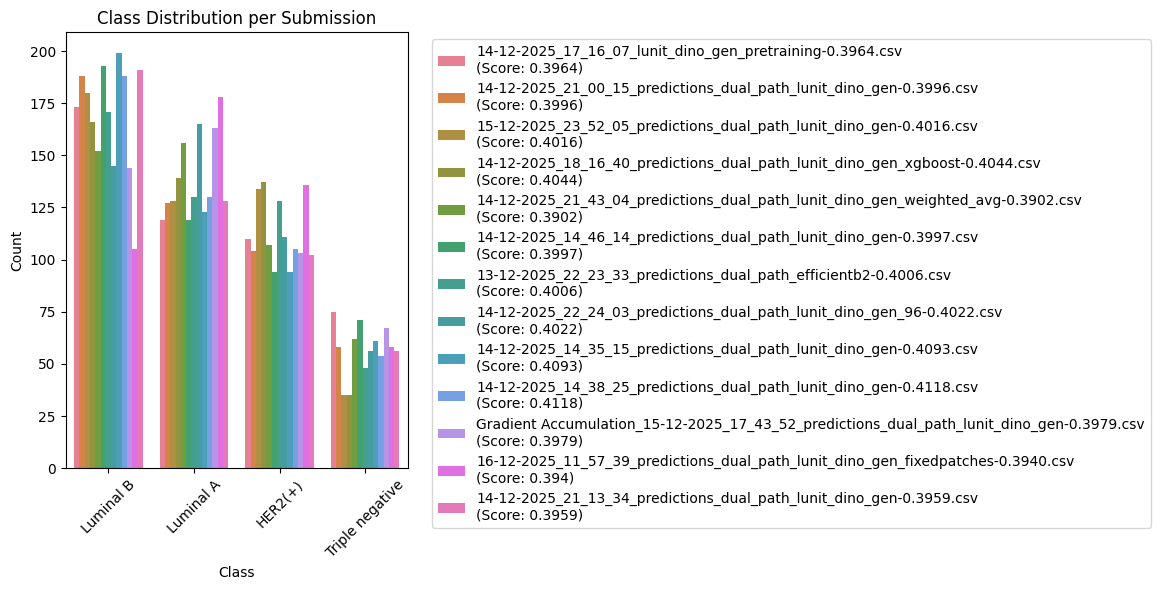


--- Similarity Report ---


/tmp/ipython-input-1375523402.py:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


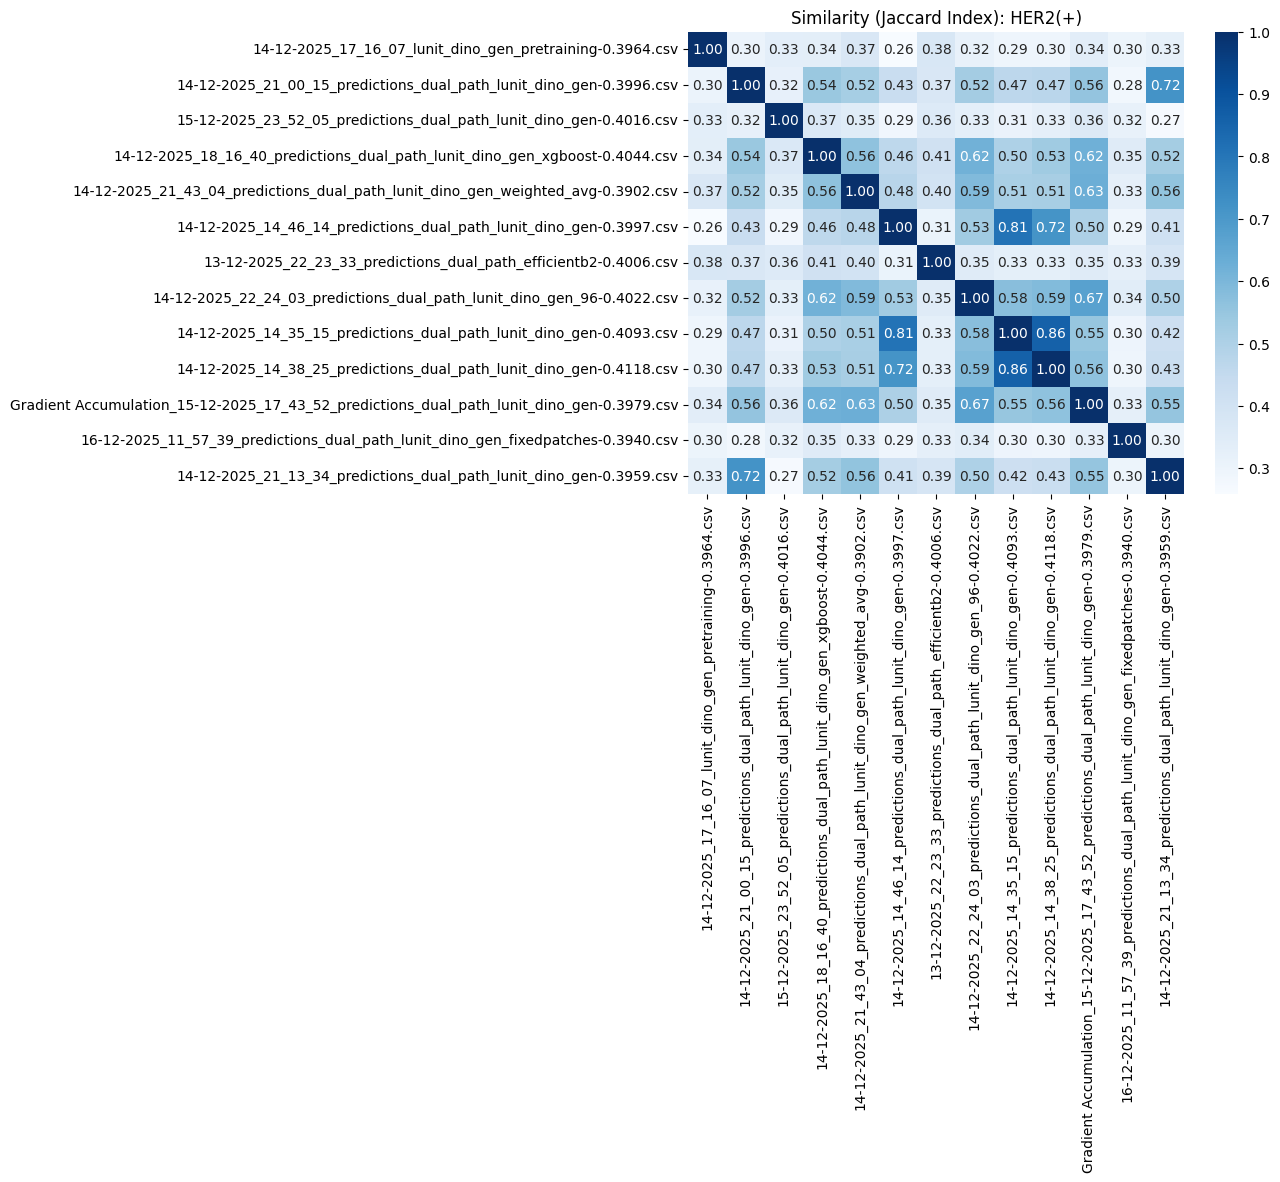

/tmp/ipython-input-1375523402.py:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


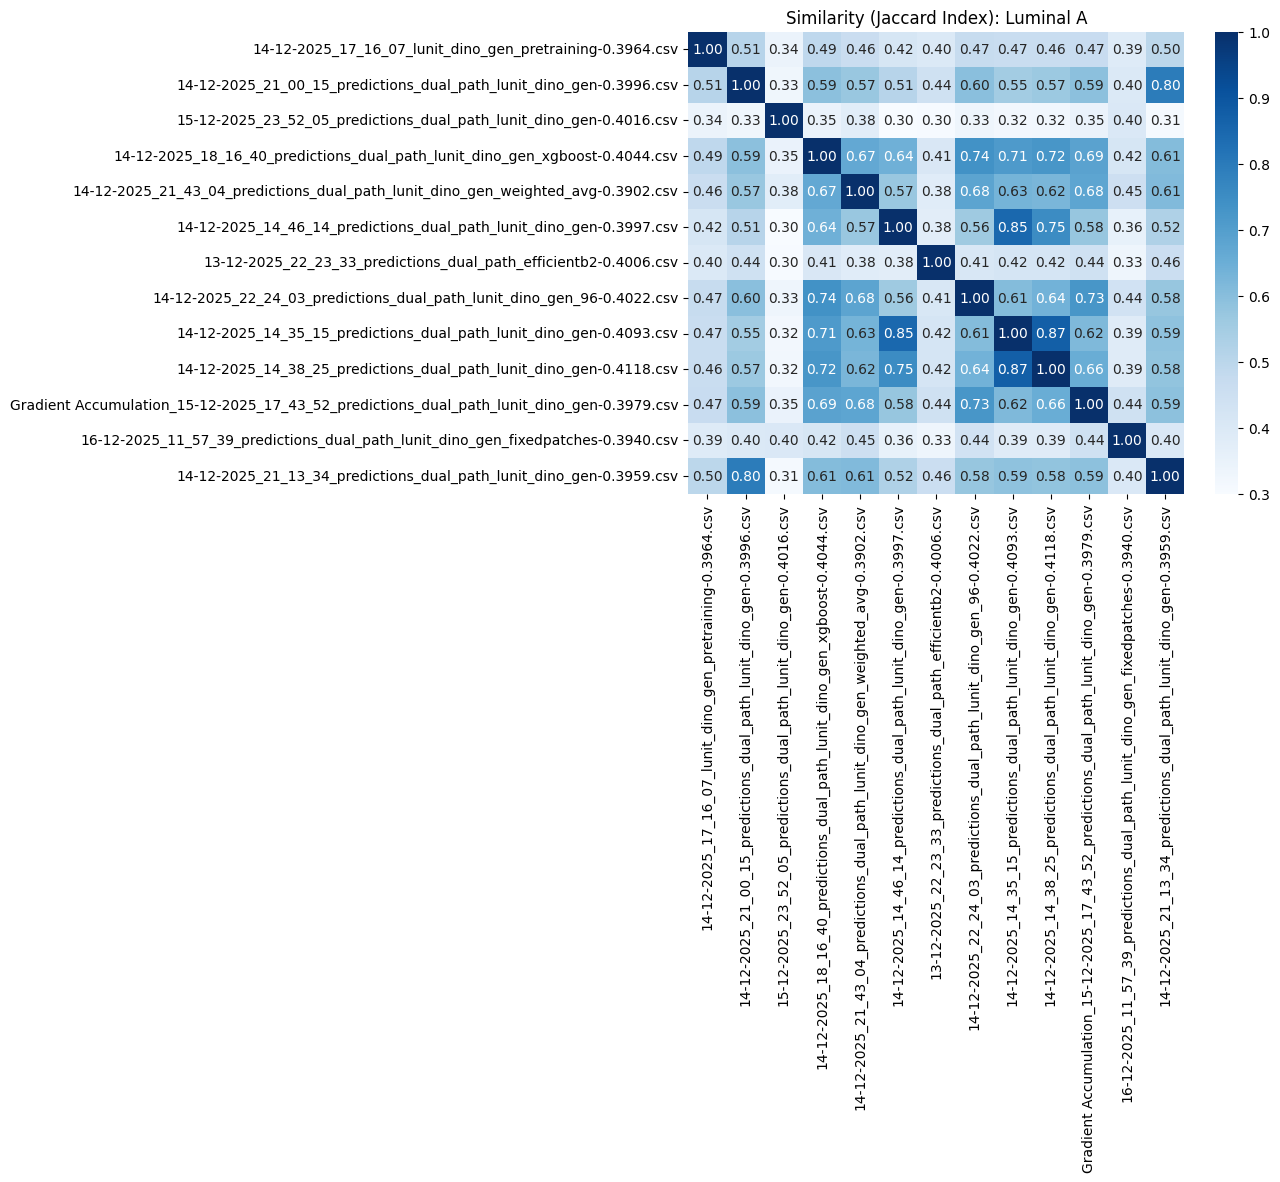

/tmp/ipython-input-1375523402.py:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


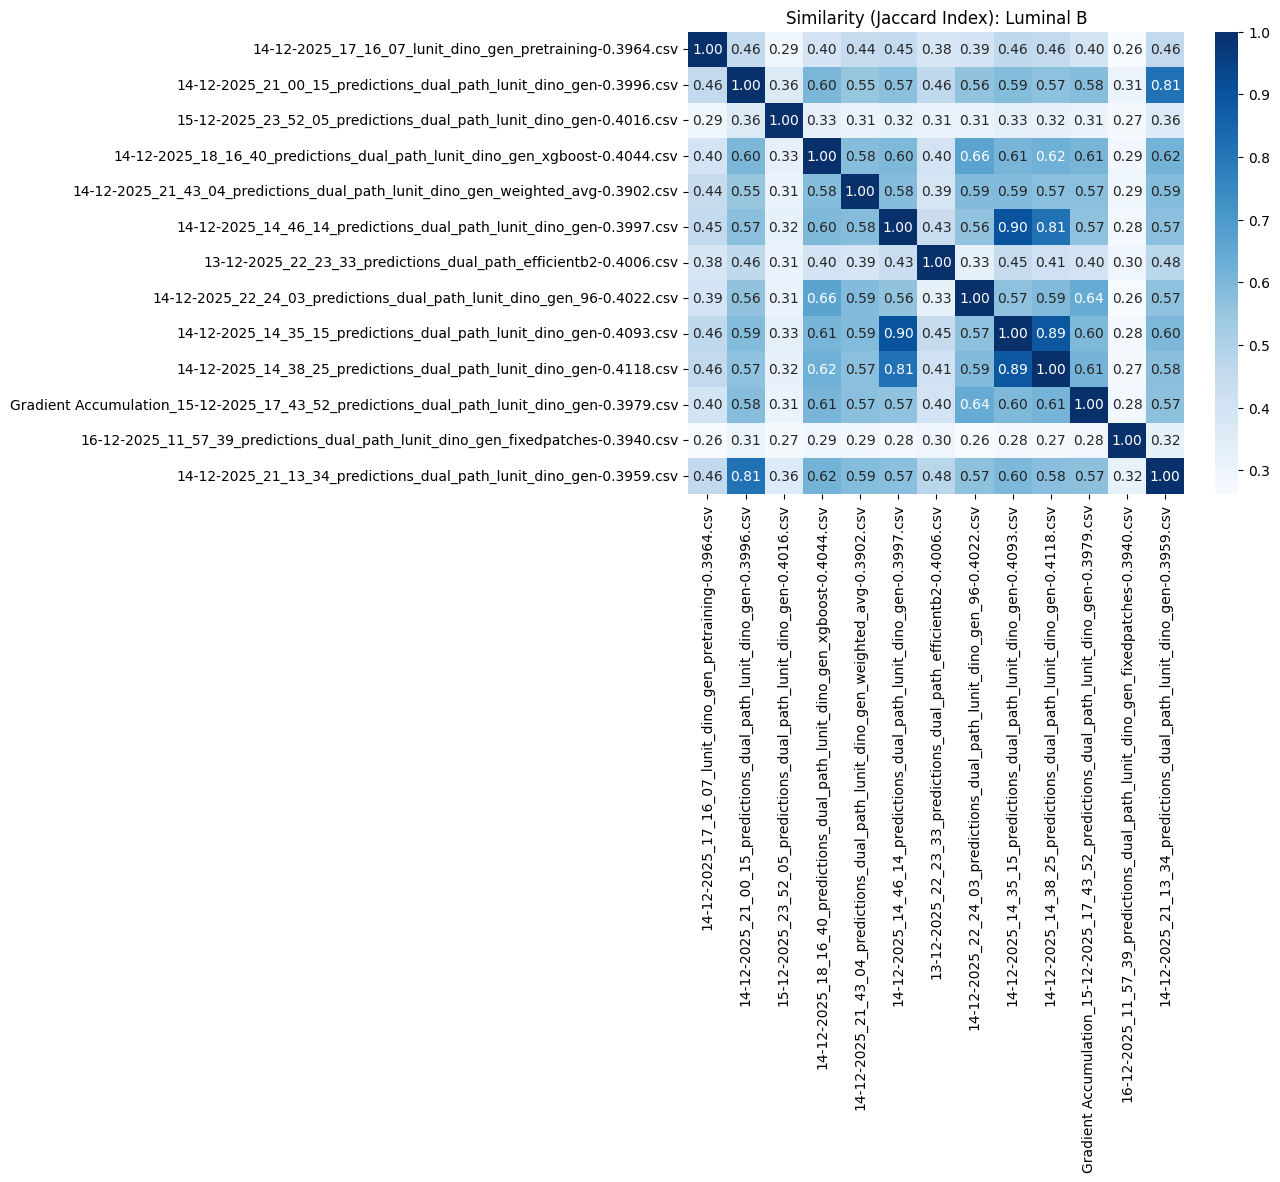

/tmp/ipython-input-1375523402.py:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


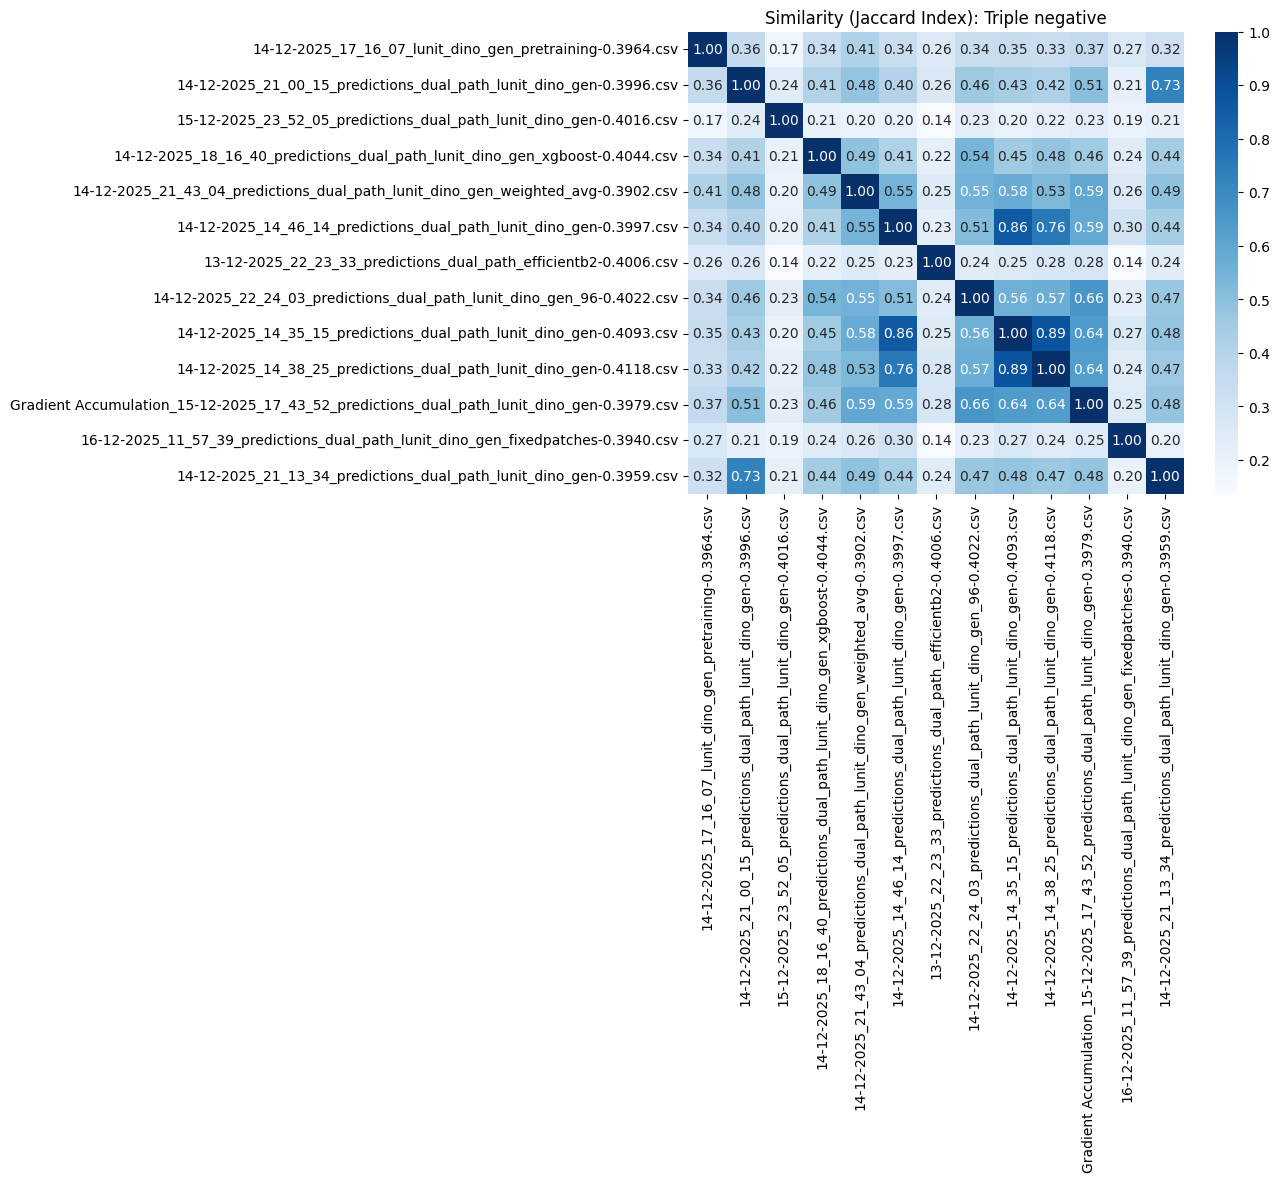

In [11]:
%cd /content/submissions-kaggle-AN2DL-c2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

def analyze_submissions(file_pattern="*.csv"):
    # 1. Find all CSV files
    csv_files = glob.glob(file_pattern)
    submissions = {}

    print(f"Found {len(csv_files)} files.")
    if len(csv_files) == 0:
        return

    # 2. Read files and extract scores
    for f in csv_files:
        # Extract score from filename (last part after '-')
        try:
            base = os.path.basename(f)
            name_part = os.path.splitext(base)[0]
            score_str = name_part.split('-')[-1]
            score = float(score_str)
        except:
            score = 0.0 # Default if parse fails

        df = pd.read_csv(f)
        # Ensure we sort by sample_index to align predictions
        if 'sample_index' in df.columns:
            df = df.sort_values('sample_index').reset_index(drop=True)
            submissions[base] = {'score': score, 'df': df}

    if not submissions:
        print("No valid submission files read.")
        return

    # 3. Analyze Distributions
    dist_data = []
    for fname, data in submissions.items():
        df = data['df']
        counts = df['label'].value_counts().reset_index()
        counts.columns = ['Class', 'Count']
        # Create a label with Score for the plot
        counts['Submission'] = f"{fname}\n(Score: {data['score']})"
        dist_data.append(counts)

    if dist_data:
        all_dists = pd.concat(dist_data)
        plt.figure(figsize=(12, 6))
        sns.barplot(data=all_dists, x='Class', y='Count', hue='Submission')
        plt.title('Class Distribution per Submission')
        plt.xticks(rotation=45)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    # 4. Pairwise Similarity Analysis
    filenames = list(submissions.keys())
    n = len(filenames)

    if n < 2:
        print("Need at least 2 files to compare similarity.")
        return

    # Initialize matrices
    total_sim_matrix = np.zeros((n, n))
    classes = sorted(all_dists['Class'].unique())
    class_sim_matrices = {c: np.zeros((n, n)) for c in classes}

    print("\n--- Similarity Report ---")
    for i in range(n):
        for j in range(n):
            name_i = filenames[i]
            name_j = filenames[j]
            df1 = submissions[name_i]['df']
            df2 = submissions[name_j]['df']

            # Total Agreement (Accuracy)
            agreement = (df1['label'] == df2['label']).mean()
            total_sim_matrix[i, j] = agreement

            # Per-Class Jaccard Similarity
            for c in classes:
                # Indices where prediction is Class C
                idx1 = set(df1[df1['label'] == c].index)
                idx2 = set(df2[df2['label'] == c].index)

                if len(idx1 | idx2) > 0:
                    jaccard = len(idx1 & idx2) / len(idx1 | idx2)
                else:
                    jaccard = 0.0 if i != j else 1.0 # Handle empty case

                class_sim_matrices[c][i, j] = jaccard

    for c in classes:
        plt.figure(figsize=(8, 6))
        sns.heatmap(class_sim_matrices[c], annot=True, fmt=".2f",
                    xticklabels=filenames, yticklabels=filenames, cmap='Blues')
        plt.title(f'Similarity (Jaccard Index): {c}')
        plt.tight_layout()
        plt.show()

# Run the function
if __name__ == "__main__":
    analyze_submissions()

/content/submissions-kaggle-AN2DL-c2
Found 13 files.


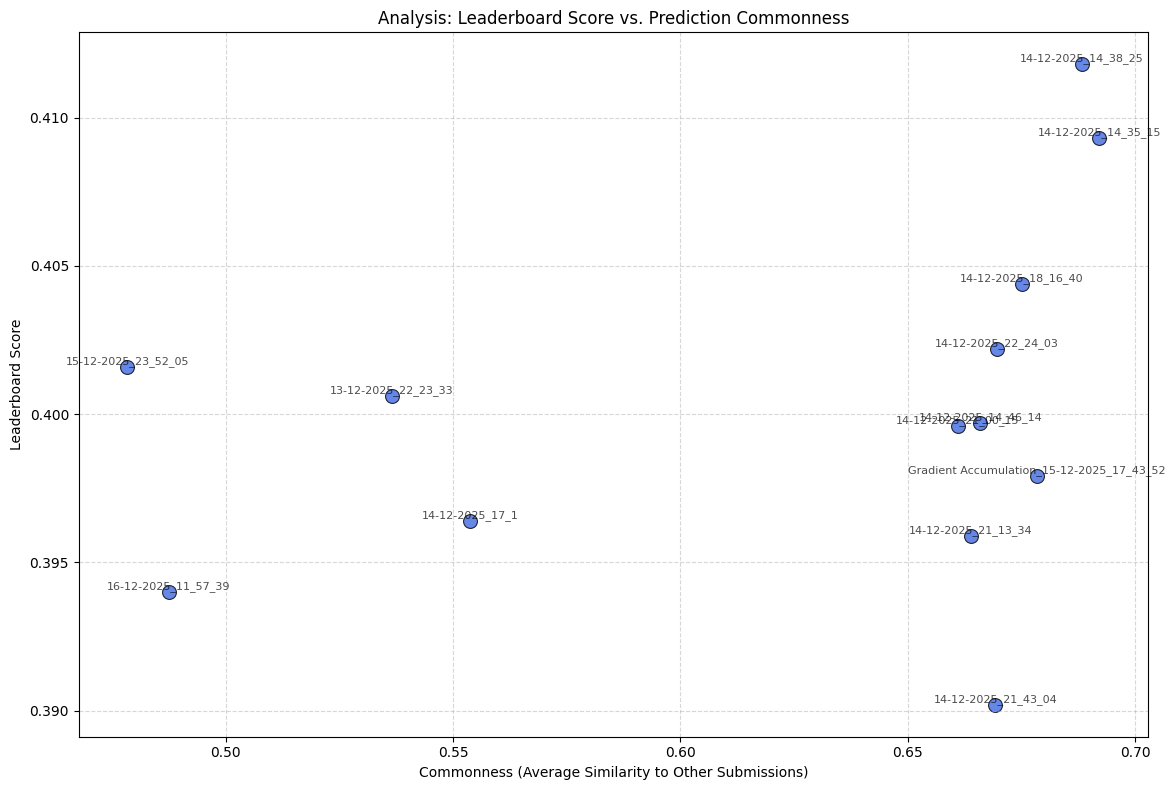

In [12]:
%cd /content/submissions-kaggle-AN2DL-c2
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

def plot_score_vs_commonness(file_pattern="*.csv"):
    # 1. Load Data
    files = glob.glob(file_pattern)
    submissions = []

    print(f"Found {len(files)} files.")

    for f in files:
        try:
            # Parse score from filename (e.g., "...-0.4006.csv")
            base_name = os.path.basename(f)
            name_no_ext = os.path.splitext(base_name)[0]

            if '-' in name_no_ext:
                score_part = name_no_ext.split('-')[-1]
                try:
                    score = float(score_part)
                except ValueError:
                    score = 0.0
            else:
                score = 0.0

            df = pd.read_csv(f)
            # Sort by index to align predictions
            if 'sample_index' in df.columns:
                df = df.sort_values('sample_index').reset_index(drop=True)

            if 'label' in df.columns:
                submissions.append({
                    'file': base_name,
                    'score': score,
                    'preds': df['label'].values
                })
        except Exception as e:
            print(f"Skipping {f}: {e}")

    n = len(submissions)
    if n == 0:
        print("No valid submissions found.")
        return

    # 2. Check consistency and stack predictions
    lengths = [len(s['preds']) for s in submissions]
    if len(set(lengths)) != 1:
        print(f"Error: Submission files have different lengths: {set(lengths)}")
        return

    # Stack predictions into a matrix (n_submissions x n_samples)
    all_preds = np.vstack([s['preds'] for s in submissions])

    # 3. Compute Similarity Matrix
    # sim_matrix[i, j] = fraction of matches between sub i and sub j
    sim_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            sim_matrix[i, j] = np.mean(all_preds[i] == all_preds[j])

    # 4. Calculate Commonness
    # Average similarity to all OTHER submissions
    if n > 1:
        # Sum of row minus 1 (diagonal self-match), divided by n-1
        commonness = (np.sum(sim_matrix, axis=1) - 1) / (n - 1)
    else:
        commonness = np.array([1.0] * n) # Default for single file

    scores = np.array([s['score'] for s in submissions])
    names = [s['file'] for s in submissions]

    # 5. Plot
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=commonness, y=scores, s=100, color='royalblue', edgecolor='k', alpha=0.8)

    # Label the points
    for i, name in enumerate(names):
        # Create a shorter label
        short_label = name.split('_predictions')[0] if '_predictions' in name else name[:15]
        # Add score to label if needed, or just keep filename
        plt.text(commonness[i], scores[i], short_label,
                 fontsize=8, ha='center', va='bottom', alpha=0.7)

    plt.title('Analysis: Leaderboard Score vs. Prediction Commonness')
    plt.xlabel('Commonness (Average Similarity to Other Submissions)')
    plt.ylabel('Leaderboard Score')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run the function
if __name__ == "__main__":
    plot_score_vs_commonness()

In [13]:
import pandas as pd
import glob
import os

# 1. SETUP: Define directory and find files
# Change this if your CSVs are in a different folder (e.g., 'predictions/')
folder_path = '/content/submissions-kaggle-AN2DL-c2/ensemble_submission(5)'
output_filename = 'ensemble_submission (5).csv'

# Use glob to find all .csv files in the folder
all_files = glob.glob(os.path.join(folder_path, '*.csv'))

# Filter out the output file so we don't include a previous run's result as input
csv_files = [f for f in all_files if os.path.basename(f) != output_filename]

print(f"Found {len(csv_files)} files to ensemble: {csv_files}")

if not csv_files:
    raise ValueError("No CSV files found in the specified directory!")

# 2. Load the dataframes
dfs = [pd.read_csv(f) for f in csv_files]

# 3. Initialize the merged dataframe with the first file's data
# We rename the 'label' column to 'label_0' to distinguish it
ensemble_df = dfs[0][['sample_index', 'label']].rename(columns={'label': 'label_0'})

# 4. Merge the other files on 'sample_index'
for i, df in enumerate(dfs[1:], 1):
    # Rename the label column for the current file
    df_temp = df[['sample_index', 'label']].rename(columns={'label': f'label_{i}'})
    # Merge on sample_index to align predictions correctly
    ensemble_df = ensemble_df.merge(df_temp, on='sample_index', how='inner')

# 5. Perform Majority Voting
# Select only the label columns
label_cols = [col for col in ensemble_df.columns if col.startswith('label_')]

# .mode(axis=1) finds the most frequent value across columns for each row
# [0] selects the first mode in case of a tie
ensemble_df['final_label'] = ensemble_df[label_cols].mode(axis=1)[0]

# 6. Create the final submission dataframe
final_submission = ensemble_df[['sample_index', 'final_label']].rename(columns={'final_label': 'label'})

# 7. Save to a new CSV file
final_submission.to_csv(output_filename, index=False)

print(f"Ensemble completed. Saved to {output_filename}")
print(final_submission.head())

Found 8 files to ensemble: ['/content/submissions-kaggle-AN2DL-c2/ensemble_submission(5)/14-12-2025_17_16_07_lunit_dino_gen_pretraining-0.3964.csv', '/content/submissions-kaggle-AN2DL-c2/ensemble_submission(5)/15-12-2025_23_52_05_predictions_dual_path_lunit_dino_gen-0.4016.csv', '/content/submissions-kaggle-AN2DL-c2/ensemble_submission(5)/14-12-2025_18_16_40_predictions_dual_path_lunit_dino_gen_xgboost-0.4044.csv', '/content/submissions-kaggle-AN2DL-c2/ensemble_submission(5)/13-12-2025_22_23_33_predictions_dual_path_efficientb2-0.4006.csv', '/content/submissions-kaggle-AN2DL-c2/ensemble_submission(5)/14-12-2025_22_24_03_predictions_dual_path_lunit_dino_gen_96-0.4022.csv', '/content/submissions-kaggle-AN2DL-c2/ensemble_submission(5)/14-12-2025_14_35_15_predictions_dual_path_lunit_dino_gen-0.4093.csv', '/content/submissions-kaggle-AN2DL-c2/ensemble_submission(5)/14-12-2025_14_38_25_predictions_dual_path_lunit_dino_gen-0.4118.csv', '/content/submissions-kaggle-AN2DL-c2/ensemble_submission